# 04 · Convergencia, eficiencia temporal y coste computacional

**Preguntas de investigación de este notebook:**

1. ¿Qué *sampler* encuentra buenas soluciones con menos *trials*?
2. ¿Esa misma ventaja se mantiene si medimos en **tiempo real de cómputo** en lugar de en número de *trials*? (un *sampler* puede necesitar pocos *trials* pero ser mucho más lento en cada uno)
3. ¿Cuánto tiempo total consume cada *sampler* a lo largo de la suite ZCAT, y cómo varía la duración de un *trial* a lo largo de la optimización?
4. ¿Existe un compromiso (*trade-off*) entre calidad de la solución final y coste computacional?

**Fuente de datos:** `master_results.csv` (un *trial* por fila), generado en `01_extraccion_datos.ipynb`.


## Configuración

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../data/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Problemas representativos para las figuras individuales (evita generar 20 gráficos
# de cada tipo); las tablas y métricas agregadas sí se calculan sobre los 20 problemas.
SELECTED_PROBLEMS = ["zcat1", "zcat5", "zcat9", "zcat13", "zcat17", "zcat20"]

TARGET_FRACTION = 0.95  # umbral para "velocidad de convergencia": % del HV final del propio sampler

## Carga de datos

In [2]:
df = pd.read_csv(DATA_DIR / "master_results.csv")
df.head()

,sampler,problem,number,value,state,duration,datetime_start,datetime_complete,params_archive_prune_policy,params_archive_unbounded,...,system_attrs_cma:optimizer:3,system_attrs_cma:optimizer:4,system_attrs_cma:optimizer:5,system_attrs_cma:optimizer:6,system_attrs_cma:optimizer:7,system_attrs_cma:optimizer:8,system_attrs_cma:optimizer:9,system_attrs_NSGAIISampler:generation,system_attrs_NSGAIIISampler:generation,system_attrs_gp:relative_params:0
0,cmaes,zcat1,0,0.183527,COMPLETE,0 days 00:00:39.033047,2026-05-13 16:23:28.920672,2026-05-13 16:24:07.953719,crowding,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cmaes,zcat1,1,0.254027,COMPLETE,0 days 00:00:42.255058,2026-05-13 16:23:28.927148,2026-05-13 16:24:11.182206,ref_dirs,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cmaes,zcat1,2,0.166690,COMPLETE,0 days 00:01:01.929140,2026-05-13 16:23:28.940678,2026-05-13 16:24:30.869818,crowding,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cmaes,zcat1,3,0.070692,COMPLETE,0 days 00:00:44.004137,2026-05-13 16:23:28.924053,2026-05-13 16:24:12.928190,mc_hv,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cmaes,zcat1,4,0.000000,COMPLETE,0 days 00:00:45.572354,2026-05-13 16:24:08.016796,2026-05-13 16:24:53.589150,ref_dirs,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Preprocesamiento

In [3]:
# Renombrar 'value' a 'hv' si es necesario
if "value" in df.columns and "hv" not in df.columns:
    df = df.rename(columns={"value": "hv"})

# El CSV guarda la duración como texto; se reconstruye como timedelta y en segundos
df["duration"] = pd.to_timedelta(df["duration"])
df["duration_s"] = df["duration"].dt.total_seconds()

# Solo los trials completados tienen una duración y un HV válidos para el análisis de convergencia
df_complete = df[df["state"] == "COMPLETE"].copy()

# Orden cronológico dentro de cada experimento (imprescindible para cummax/cumsum)
df_complete = df_complete.sort_values(["sampler", "problem", "number"]).reset_index(drop=True)

print(f"Trials totales: {len(df):,}  |  Trials completados: {len(df_complete):,}")
print(f"Samplers: {sorted(df_complete['sampler'].unique())}")
print(f"Problemas: {df_complete['problem'].nunique()}")

Trials totales: 7,004  |  Trials completados: 3,820
Samplers: ['cmaes', 'gp', 'nsgaii', 'nsgaiii', 'qmc', 'random', 'tpe']
Problemas: 20


## Cálculo de métricas de convergencia

Para cada combinación (*sampler*, problema) se calcula, en orden cronológico:

- **`best_so_far`** — mejor HV visto hasta el momento (máximo acumulado).
- **`delta_hv`** — mejora incremental respecto al trial anterior.
- **`cum_duration_s`** — tiempo de cómputo acumulado (segundos), es decir, la suma de la duración de todos los *trials* completados hasta ese punto. Es el eje temporal "real" que se usará para las curvas de convergencia por tiempo.


In [4]:
group_cols = ["sampler", "problem"]

df_complete["best_so_far"] = (
    df_complete.groupby(group_cols)["hv"].cummax()
)

df_complete["delta_hv"] = (
    df_complete.groupby(group_cols)["best_so_far"]
    .diff()
    .fillna(df_complete["best_so_far"])
)

df_complete["cum_duration_s"] = (
    df_complete.groupby(group_cols)["duration_s"].cumsum()
)
df_complete["cum_duration_min"] = df_complete["cum_duration_s"] / 60

df_filtered = df_complete[df_complete["problem"].isin(SELECTED_PROBLEMS)].copy()

print("Métricas de convergencia calculadas (best_so_far, delta_hv, cum_duration).")

Métricas de convergencia calculadas (best_so_far, delta_hv, cum_duration).


## Curvas de convergencia por número de trial

Vista clásica: eje X = número de *trial*. Es la forma habitual de comparar samplers, pero **no** refleja el coste computacional real de cada uno.


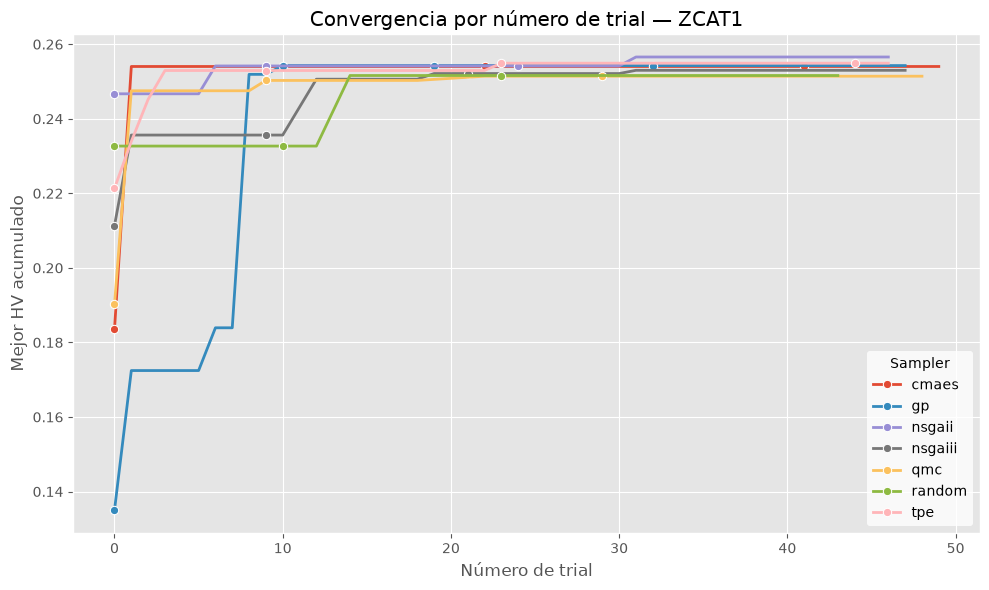

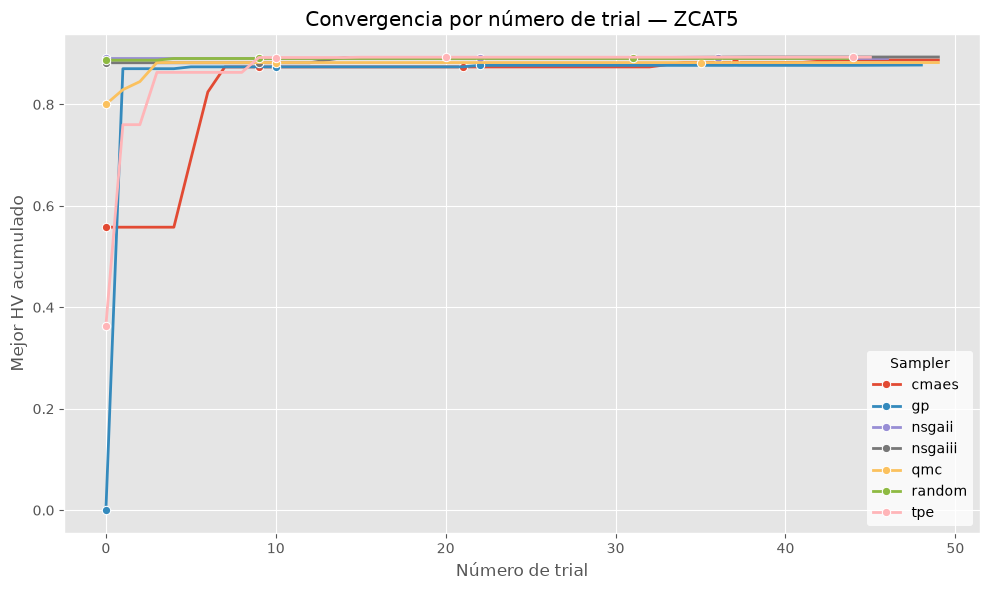

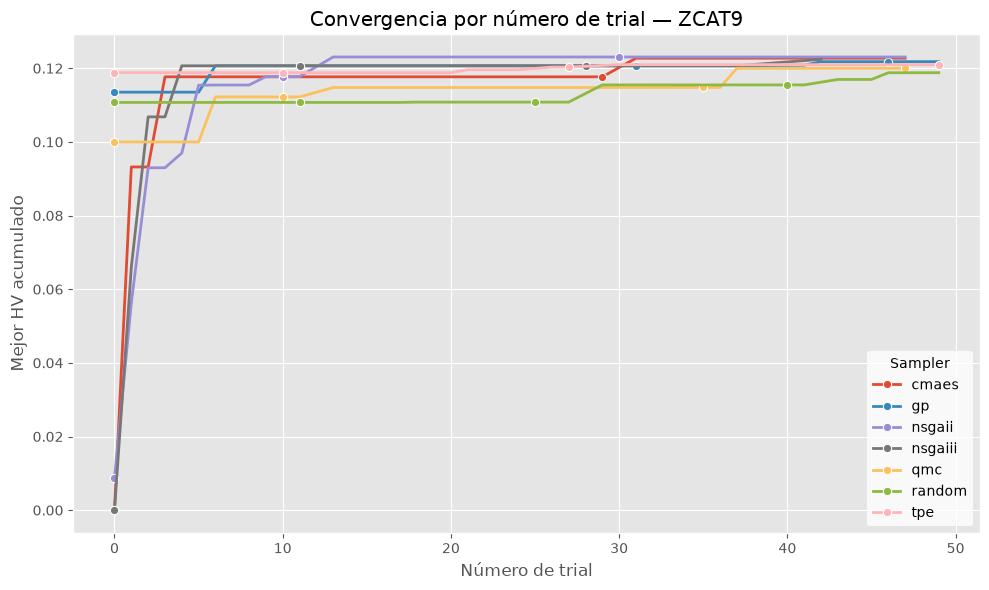

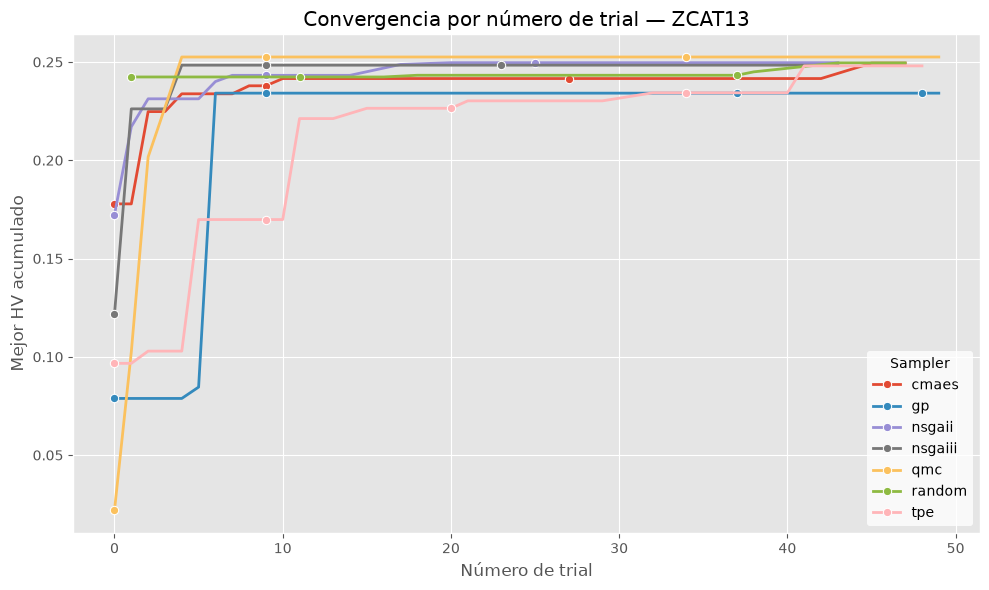

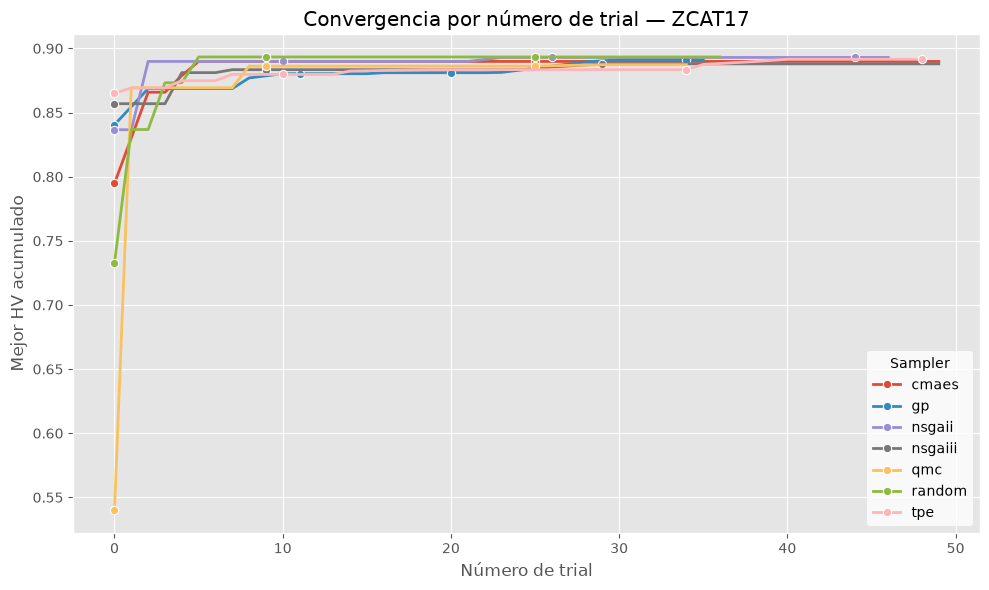

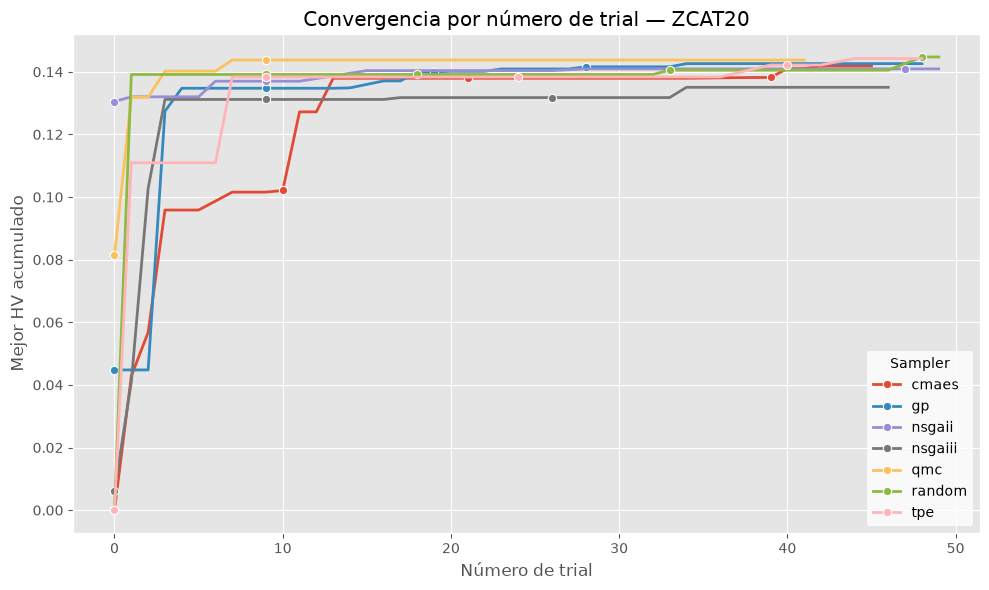

In [5]:
for problem in SELECTED_PROBLEMS:
    df_prob = df_filtered[df_filtered["problem"] == problem]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        ax=ax,
        data=df_prob,
        x="number",
        y="best_so_far",
        hue="sampler",
        linewidth=2.0,
        marker="o",
        markevery=max(1, len(df_prob) // 20),
    )
    ax.set_title(f"Convergencia por número de trial — {problem.upper()}")
    ax.set_xlabel("Número de trial")
    ax.set_ylabel("Mejor HV acumulado")
    ax.legend(title="Sampler", frameon=True, facecolor="white", edgecolor="none")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"convergencia_trial_{problem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Curvas de convergencia por tiempo real de cómputo

Misma información, pero con el eje X sustituido por el **tiempo acumulado de cómputo** (minutos). Esta vista es la que realmente importa a la hora de decidir qué *sampler* usar bajo un presupuesto de tiempo limitado: dos samplers pueden alcanzar el mismo HV en el mismo número de *trials*, pero uno puede tardar mucho más tiempo real en cada uno de ellos (por ejemplo, por el coste de ajustar un modelo sustituto, como ocurre en GP).


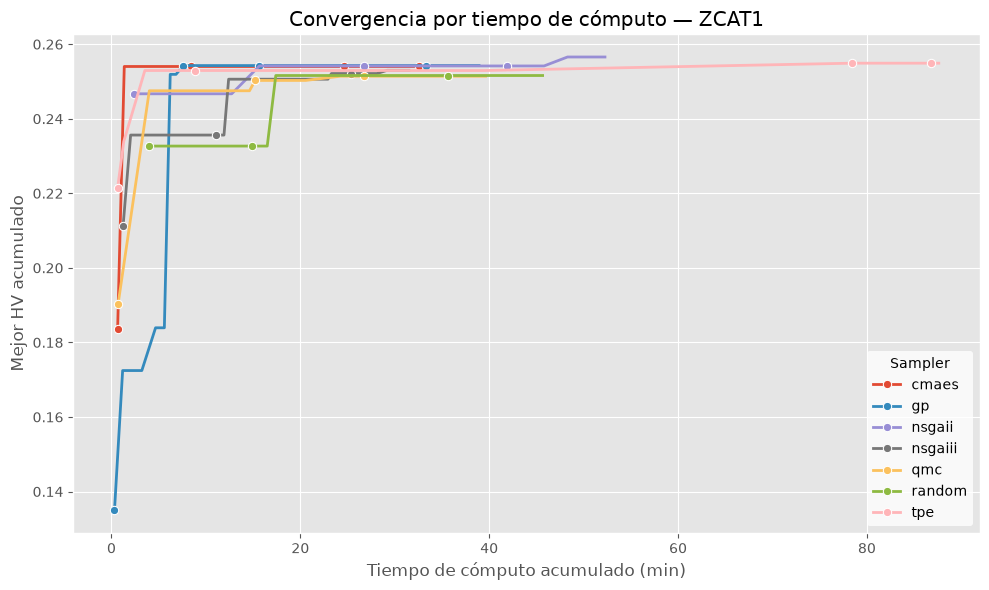

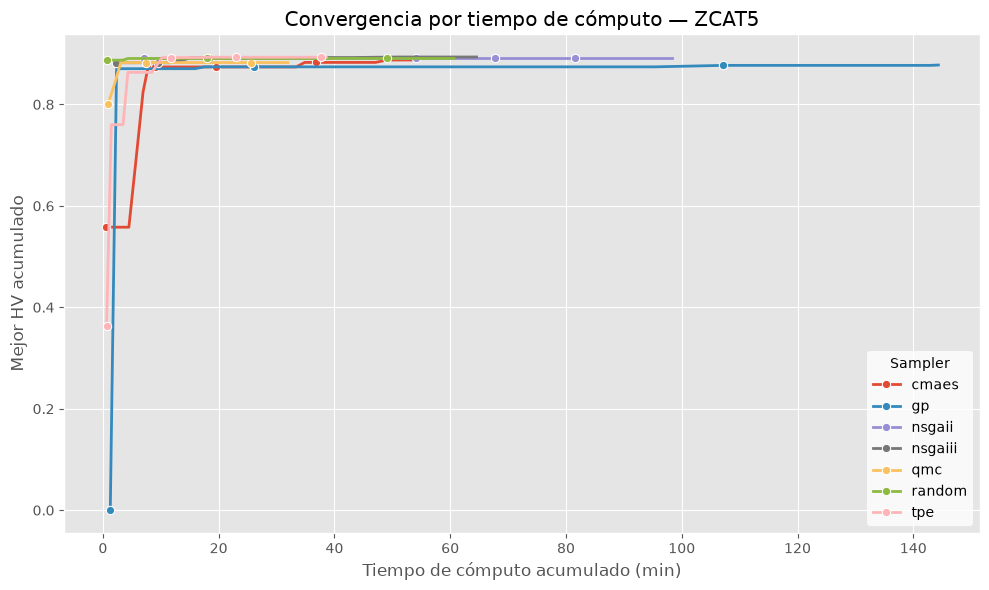

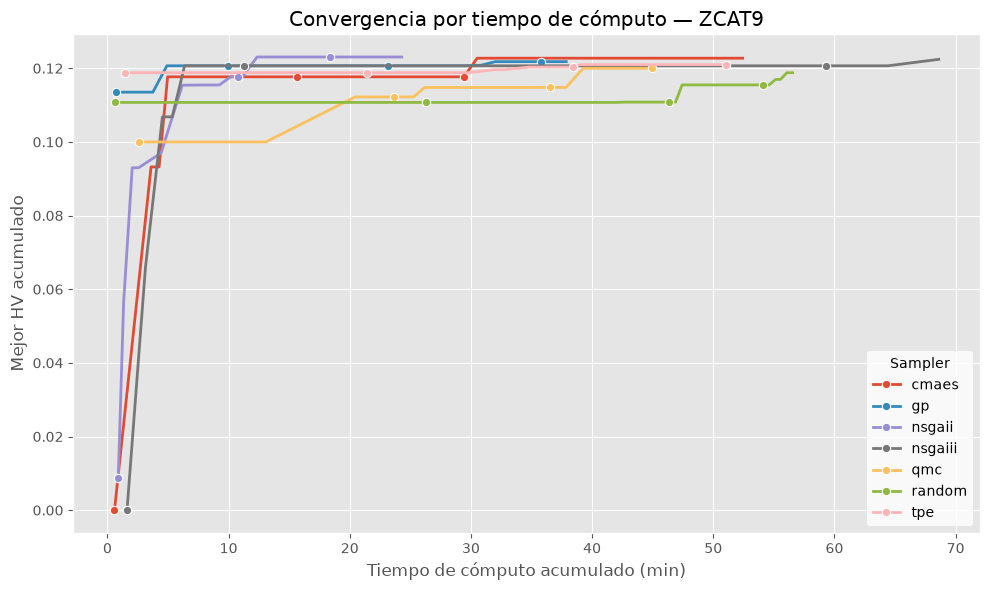

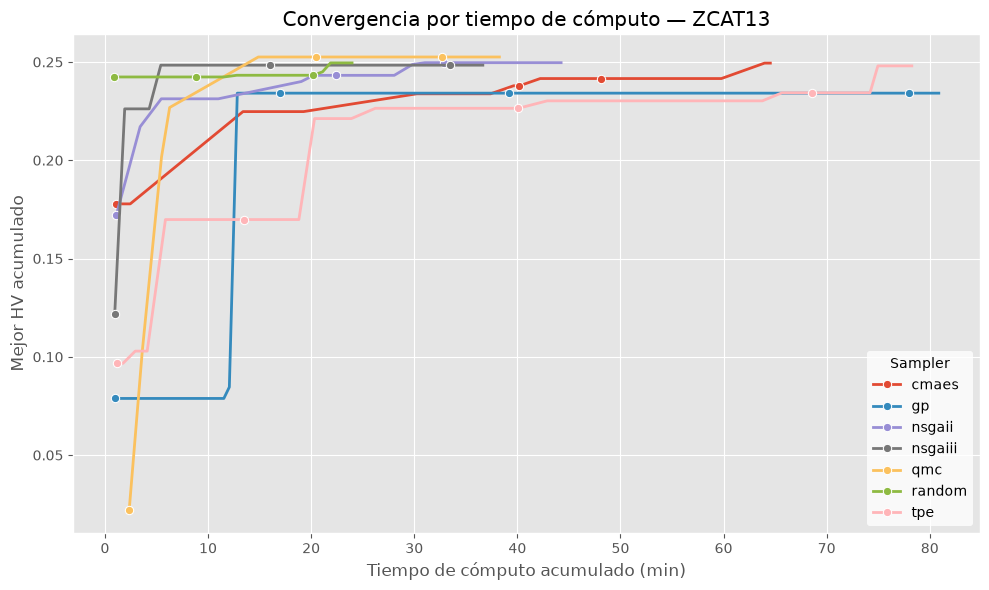

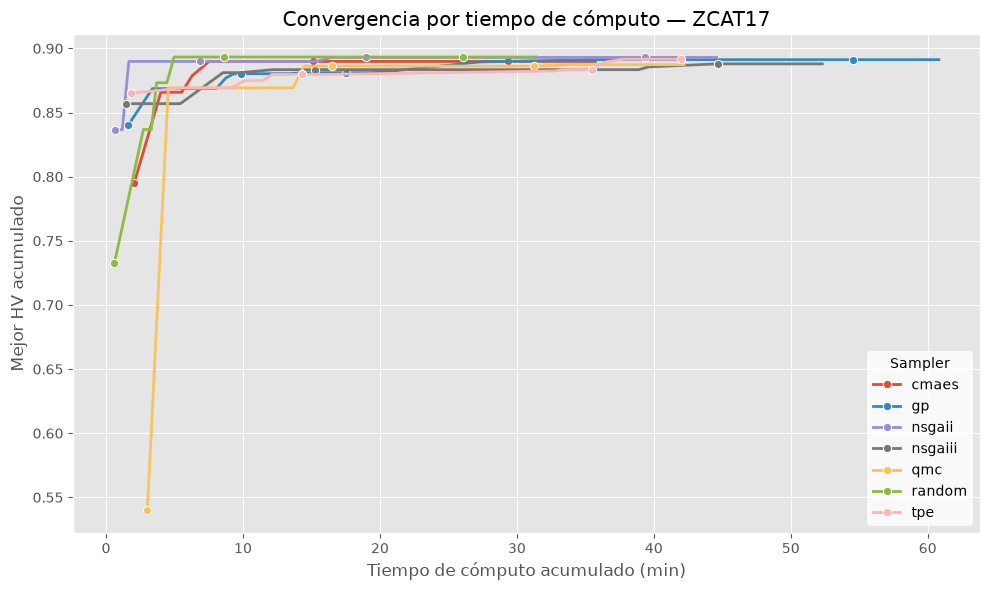

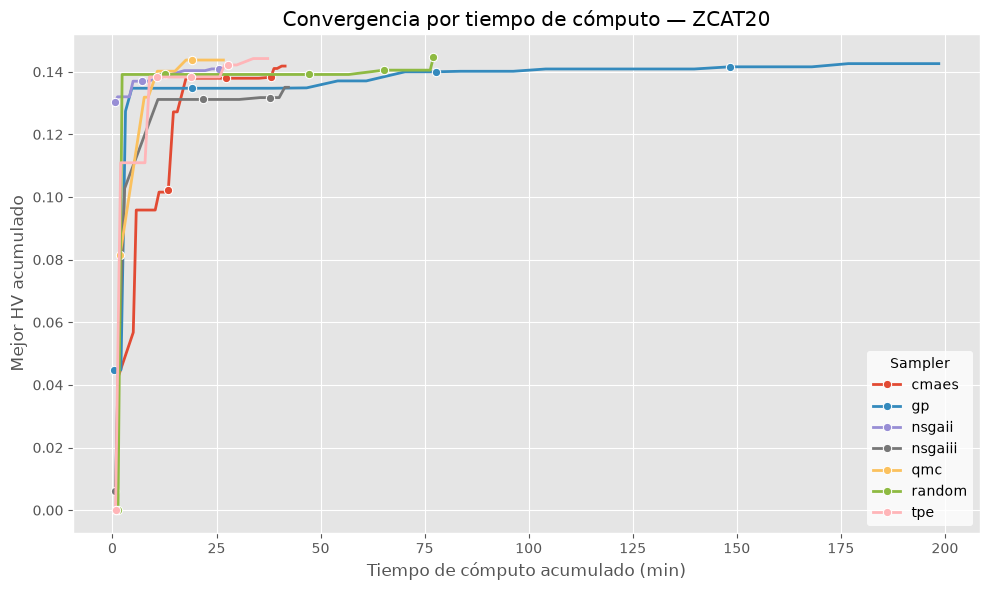

In [6]:
for problem in SELECTED_PROBLEMS:
    df_prob = df_filtered[df_filtered["problem"] == problem]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        ax=ax,
        data=df_prob,
        x="cum_duration_min",
        y="best_so_far",
        hue="sampler",
        linewidth=2.0,
        marker="o",
        markevery=max(1, len(df_prob) // 20),
    )
    ax.set_title(f"Convergencia por tiempo de cómputo — {problem.upper()}")
    ax.set_xlabel("Tiempo de cómputo acumulado (min)")
    ax.set_ylabel("Mejor HV acumulado")
    ax.legend(title="Sampler", frameon=True, facecolor="white", edgecolor="none")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"convergencia_tiempo_{problem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Ganancia incremental por trial

Muestra en qué fase de la optimización se producen las mejoras más importantes (exploración inicial vs. explotación fina al final).


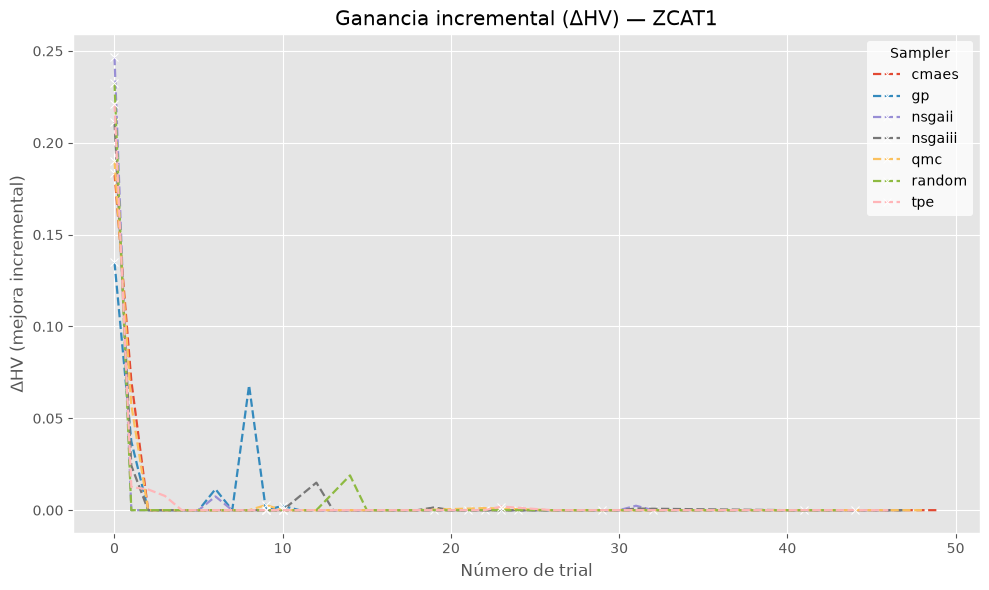

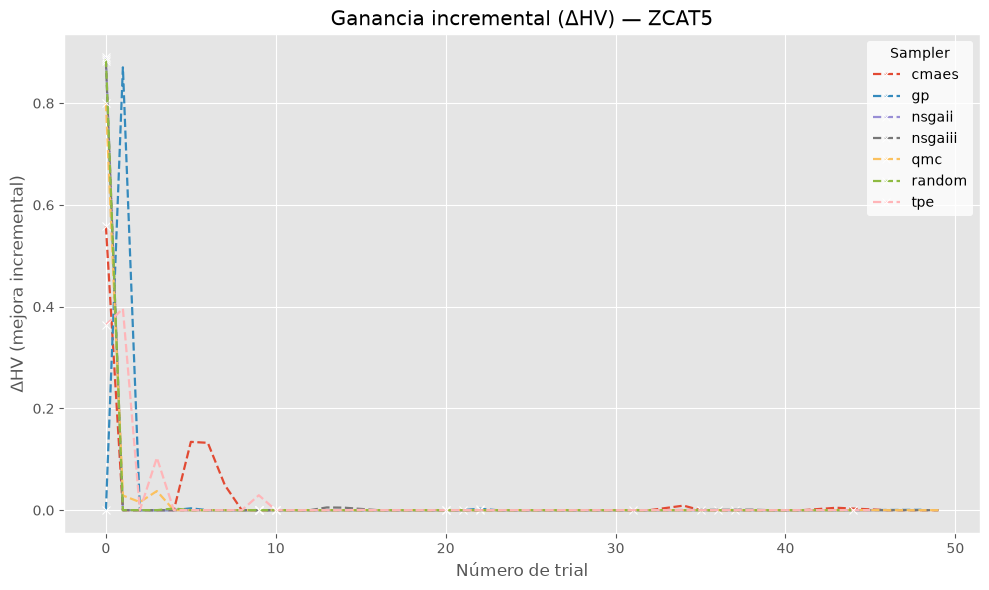

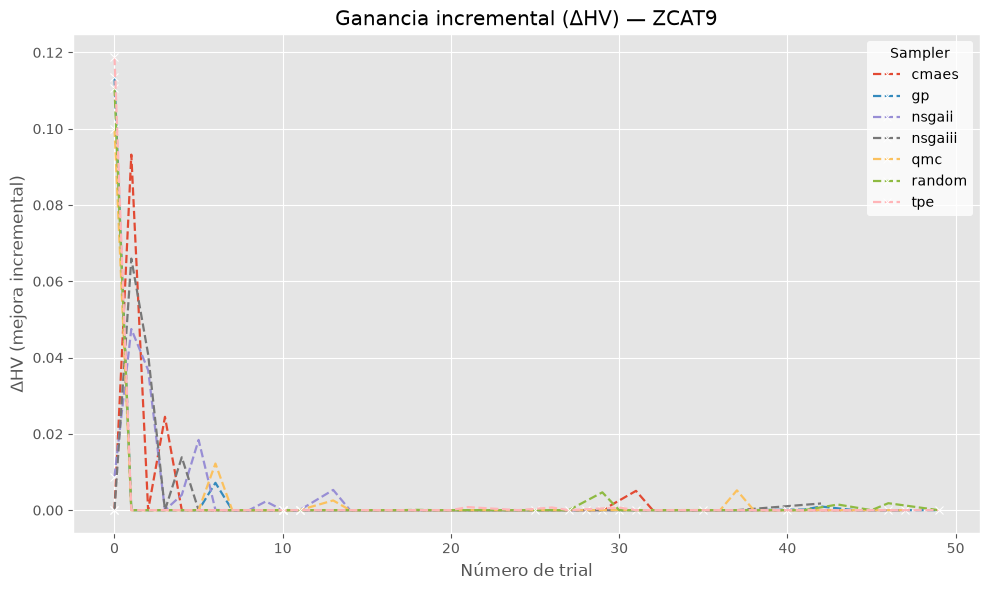

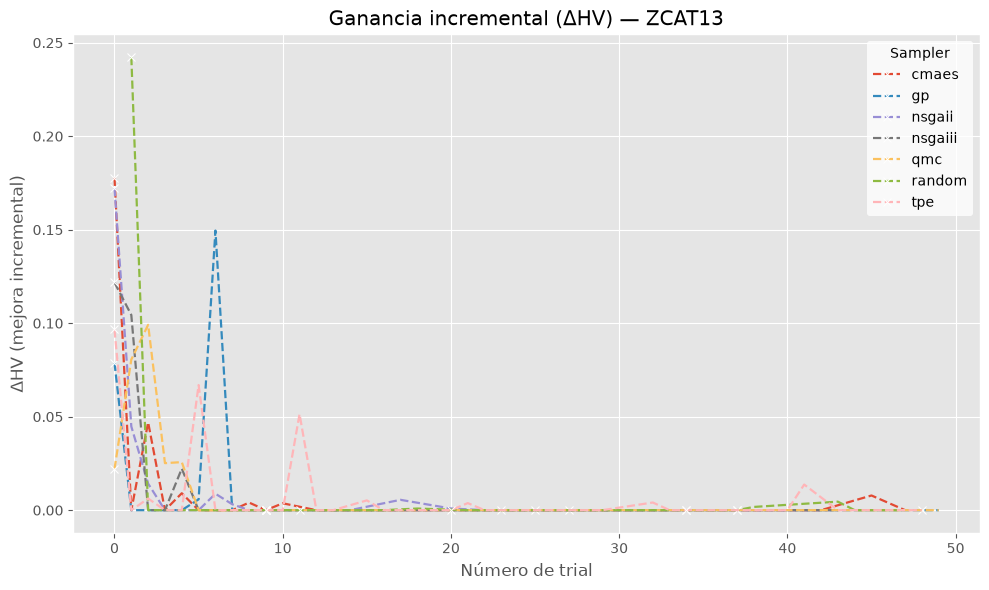

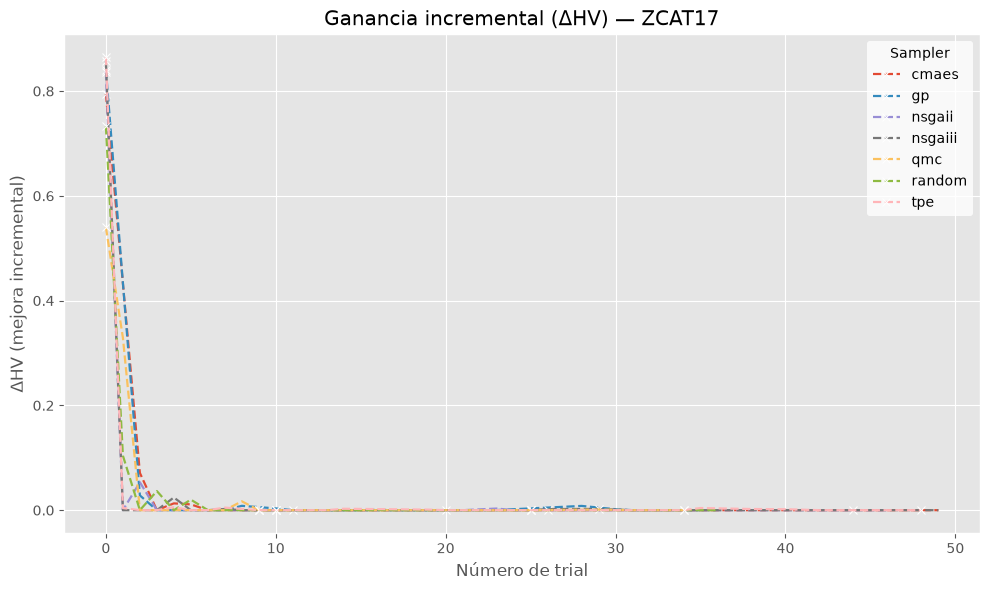

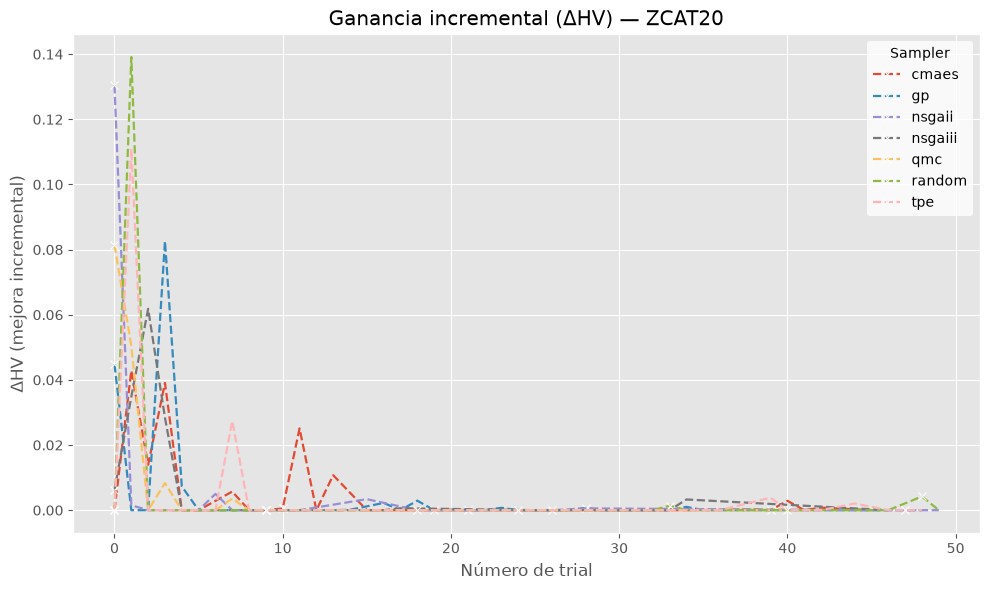

In [7]:
for problem in SELECTED_PROBLEMS:
    df_prob = df_filtered[df_filtered["problem"] == problem]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        ax=ax,
        data=df_prob,
        x="number",
        y="delta_hv",
        hue="sampler",
        linewidth=1.6,
        linestyle="--",
        marker="x",
        markevery=max(1, len(df_prob) // 20),
    )
    ax.set_title(rf"Ganancia incremental ($\Delta$HV) — {problem.upper()}")
    ax.set_xlabel("Número de trial")
    ax.set_ylabel(r"$\Delta$HV (mejora incremental)")
    ax.legend(title="Sampler", frameon=True, facecolor="white", edgecolor="none")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"ganancia_incremental_{problem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Velocidad de convergencia: trials y tiempo hasta el 95% del HV final

Para cada (*sampler*, problema), sobre los **20 problemas completos**: ¿cuántos *trials* y cuántos minutos de cómputo son necesarios para alcanzar el 95% del mejor HV que ese *sampler* llegará a encontrar en ese problema?


In [8]:
speed_records = []

for (sampler, problem), group in df_complete.groupby(group_cols):
    final_best = group["best_so_far"].max()
    target_hv = TARGET_FRACTION * final_best

    reached = group[group["best_so_far"] >= target_hv]

    if not reached.empty:
        trials_needed = int(reached["number"].iloc[0])
        time_needed_min = reached["cum_duration_min"].iloc[0]
    else:
        trials_needed = np.nan
        time_needed_min = np.nan

    speed_records.append({
        "sampler": sampler,
        "problem": problem,
        "hv_final": round(final_best, 6),
        "target_hv_95pct": round(target_hv, 6),
        "trials_al_95pct": trials_needed,
        "minutos_al_95pct": round(time_needed_min, 3) if pd.notna(time_needed_min) else np.nan,
    })

df_speed = pd.DataFrame(speed_records)
df_speed.to_csv(DATA_DIR / "convergence_speed.csv", index=False)

df_speed.head(10)

,sampler,problem,hv_final,target_hv_95pct,trials_al_95pct,minutos_al_95pct
0,cmaes,zcat1,0.254027,0.241325,1,1.355
1,cmaes,zcat10,0.112726,0.107090,3,6.668
2,cmaes,zcat11,0.210841,0.200299,2,1.569
3,cmaes,zcat12,0.195056,0.185304,0,0.487
4,cmaes,zcat13,0.249413,0.236943,8,39.628
5,cmaes,zcat14,0.135265,0.128502,1,1.028
6,cmaes,zcat15,0.196426,0.186605,1,1.681
7,cmaes,zcat16,0.137158,0.130300,3,2.692
8,cmaes,zcat17,0.889857,0.845364,2,3.996
9,cmaes,zcat18,0.142671,0.135537,9,22.127


In [9]:
trials_pivot = df_speed.pivot(index="problem", columns="sampler", values="trials_al_95pct")
minutes_pivot = df_speed.pivot(index="problem", columns="sampler", values="minutos_al_95pct")

print("Trials necesarios para alcanzar el 95% del HV final (por problema y sampler):")
display(trials_pivot)

print("\nMinutos de cómputo necesarios para alcanzar el 95% del HV final:")
display(minutes_pivot)

Trials necesarios para alcanzar el 95% del HV final (por problema y sampler):


sampler,cmaes,gp,nsgaii,nsgaiii,qmc,random,tpe
problem,,,,,,,
zcat1,1,8,0,12,1,14,2
zcat10,3,0,6,5,0,2,2
zcat11,2,7,6,3,9,10,7
zcat12,0,7,2,30,7,8,12
zcat13,8,6,6,4,4,1,41
zcat14,1,5,1,9,8,5,10
zcat15,1,3,11,4,1,4,10
zcat16,3,9,6,0,5,6,3
zcat17,2,2,2,0,1,3,0



Minutos de cómputo necesarios para alcanzar el 95% del HV final:


sampler,cmaes,gp,nsgaii,nsgaiii,qmc,random,tpe
problem,,,,,,,
zcat1,1.355,6.221,2.415,12.406,4.006,17.400,2.630
zcat10,6.668,1.447,5.487,5.922,0.547,3.198,2.965
zcat11,1.569,22.746,7.138,8.929,18.137,8.876,11.049
zcat12,0.487,7.519,2.564,24.326,11.606,5.016,10.745
zcat13,39.628,12.836,19.042,5.415,14.875,0.926,74.966
zcat14,1.028,16.510,1.040,11.218,8.855,6.445,39.844
zcat15,1.681,5.833,11.253,9.513,2.092,8.657,8.843
zcat16,2.692,9.588,6.799,0.912,8.892,8.834,2.543
zcat17,3.996,3.383,1.663,1.423,4.546,3.693,1.831


In [10]:
mean_speed = (
    df_speed
    .groupby("sampler")[["trials_al_95pct", "minutos_al_95pct"]]
    .mean()
    .sort_values("minutos_al_95pct")
)

print("Medias globales (los 20 problemas). Ordenado por tiempo hasta el 95%:")
mean_speed

Medias globales (los 20 problemas). Ordenado por tiempo hasta el 95%:


,trials_al_95pct,minutos_al_95pct
sampler,,
nsgaii,5.00,7.31080
nsgaiii,7.25,10.00935
cmaes,5.45,10.10235
random,7.40,10.83200
gp,6.10,11.41395
tpe,7.65,12.68715
qmc,6.80,13.17055


## Duración total y coste computacional por sampler

Hasta ahora se ha medido la velocidad de convergencia *relativa* al HV final de cada sampler. Esta sección analiza el **coste computacional en términos absolutos**: cuánto tiempo consume cada *sampler*, en total y por *trial*, a lo largo de toda la suite ZCAT.


In [11]:
duration_by_study = (
    df_complete
    .groupby(group_cols)
    .agg(
        n_trials=("number", "count"),
        total_duration_s=("duration_s", "sum"),
        mean_trial_duration_s=("duration_s", "mean"),
    )
    .reset_index()
)

duration_by_study["total_duration_min"] = duration_by_study["total_duration_s"] / 60
duration_by_study.head()

,sampler,problem,n_trials,total_duration_s,mean_trial_duration_s,total_duration_min
0,cmaes,zcat1,30,2018.320947,67.277365,33.638682
1,cmaes,zcat10,27,3558.977160,131.813969,59.316286
2,cmaes,zcat11,28,2899.300611,103.546450,48.321677
3,cmaes,zcat12,24,1330.035037,55.418127,22.167251
4,cmaes,zcat13,26,3872.100305,148.926935,64.535005


In [12]:
duration_by_sampler = (
    duration_by_study
    .groupby("sampler")
    .agg(
        total_duration_hours=("total_duration_s", lambda s: s.sum() / 3600),
        mean_study_duration_min=("total_duration_min", "mean"),
        mean_trial_duration_s=("mean_trial_duration_s", "mean"),
    )
)
duration_by_sampler["trials_per_minute"] = 60 / duration_by_sampler["mean_trial_duration_s"]
duration_by_sampler = duration_by_sampler.sort_values("total_duration_hours")

duration_by_sampler.round(3)

,total_duration_hours,mean_study_duration_min,mean_trial_duration_s,trials_per_minute
sampler,,,,
nsgaiii,13.100,39.299,99.589,0.602
random,14.417,43.252,96.285,0.623
qmc,14.664,43.991,104.786,0.573
cmaes,15.589,46.766,103.260,0.581
nsgaii,15.597,46.790,104.026,0.577
tpe,18.550,55.649,100.266,0.598
gp,29.157,87.472,176.018,0.341


In [13]:
duration_by_sampler.round(3).to_csv(DATA_DIR / "duration_by_sampler.csv")
print(f"Guardado: {(DATA_DIR / 'duration_by_sampler.csv').resolve()}")

Guardado: D:\tfm\tfm\data\processed\duration_by_sampler.csv


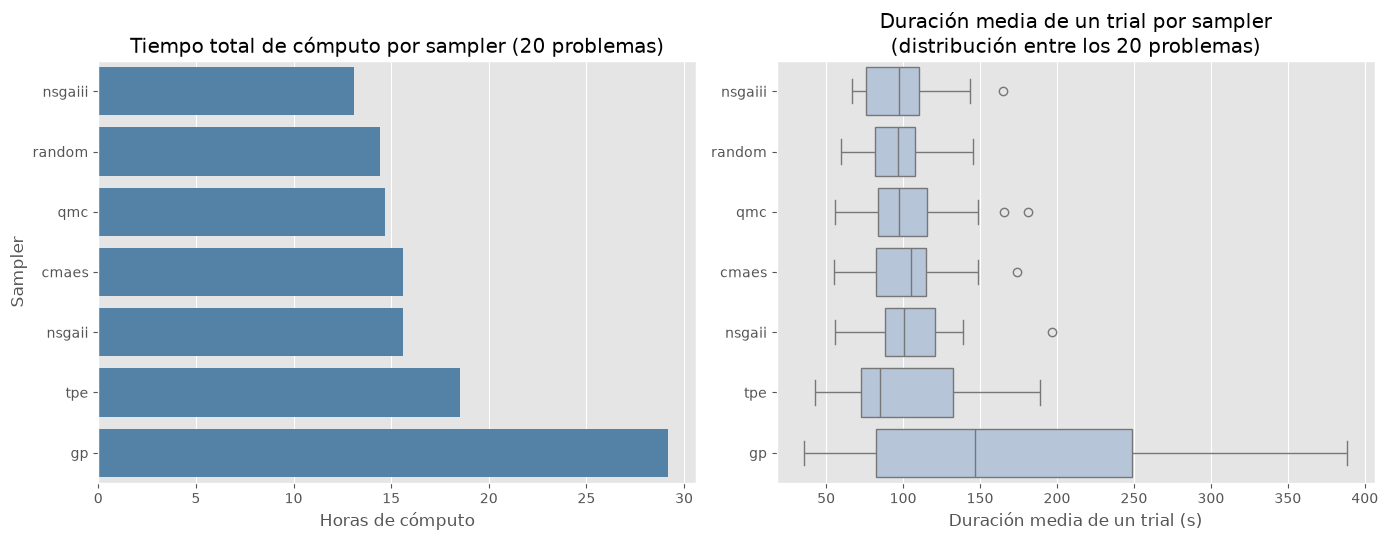

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

order = duration_by_sampler.index.tolist()

sns.barplot(
    x=duration_by_sampler["total_duration_hours"],
    y=order,
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Tiempo total de cómputo por sampler (20 problemas)")
axes[0].set_xlabel("Horas de cómputo")
axes[0].set_ylabel("Sampler")

sns.boxplot(
    data=duration_by_study,
    x="mean_trial_duration_s",
    y="sampler",
    order=order,
    ax=axes[1],
    color="lightsteelblue",
)
axes[1].set_title("Duración media de un trial por sampler\n(distribución entre los 20 problemas)")
axes[1].set_xlabel("Duración media de un trial (s)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "duracion_por_sampler.png", dpi=300, bbox_inches="tight")
plt.show()

### ¿Se ralentizan los trials a medida que avanza la optimización?

Algunos *samplers* (especialmente los basados en modelos sustitutos, como GP) tienden a volverse más lentos a medida que acumulan observaciones, porque cada nuevo *trial* requiere reajustar un modelo cada vez más grande.


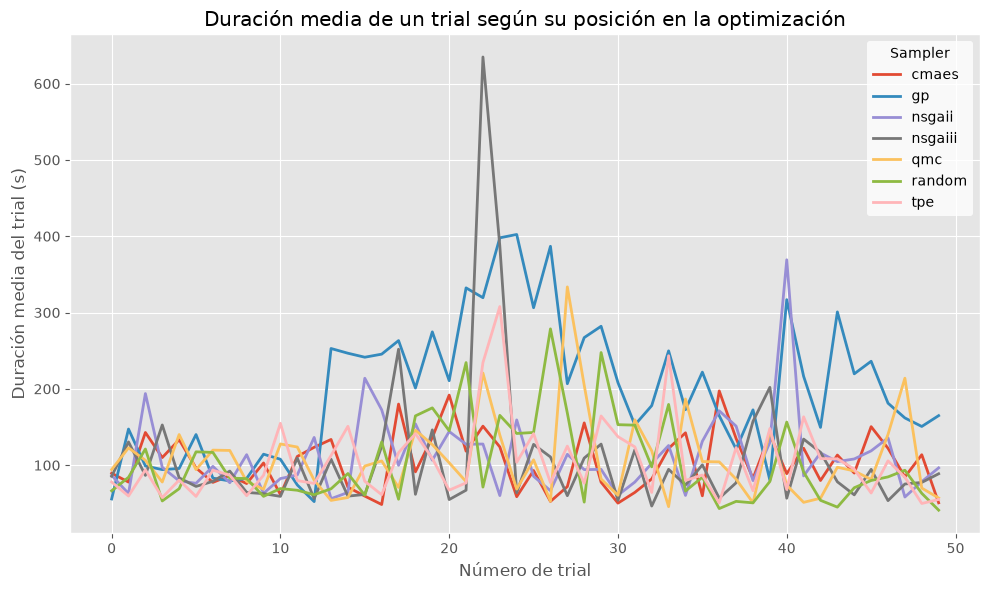

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    ax=ax,
    data=df_complete,
    x="number",
    y="duration_s",
    hue="sampler",
    estimator="mean",
    errorbar=None,
    linewidth=2.0,
)

ax.set_title("Duración media de un trial según su posición en la optimización")
ax.set_xlabel("Número de trial")
ax.set_ylabel("Duración media del trial (s)")
ax.legend(title="Sampler", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "duracion_trial_vs_numero.png", dpi=300, bbox_inches="tight")
plt.show()

## Relación coste-beneficio: calidad final vs. tiempo de cómputo

Cada punto es un estudio (combinación *sampler* + problema): en el eje X, el tiempo total invertido; en el eje Y, el HV final alcanzado. Un buen *sampler* debería situarse en la esquina superior izquierda (alto HV, poco tiempo).


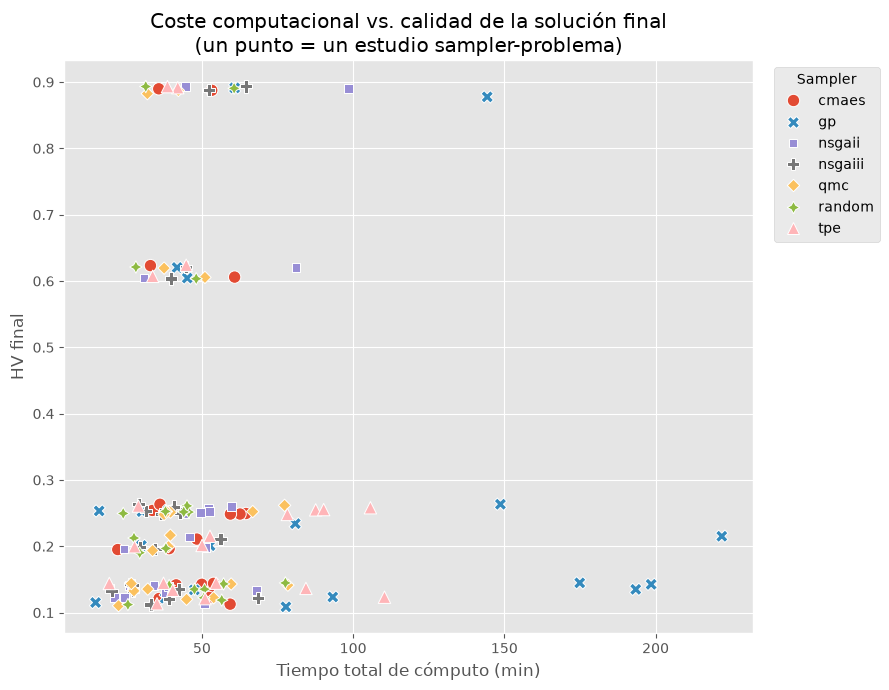

In [16]:
final_hv = (
    df_complete
    .groupby(group_cols)["best_so_far"]
    .max()
    .reset_index()
    .rename(columns={"best_so_far": "hv_final"})
)

cost_benefit = final_hv.merge(duration_by_study, on=group_cols)

fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=cost_benefit,
    x="total_duration_min",
    y="hv_final",
    hue="sampler",
    style="sampler",
    s=80,
    ax=ax,
)

ax.set_title("Coste computacional vs. calidad de la solución final\n(un punto = un estudio sampler-problema)")
ax.set_xlabel("Tiempo total de cómputo (min)")
ax.set_ylabel("HV final")
ax.legend(title="Sampler", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "coste_beneficio.png", dpi=300, bbox_inches="tight")
plt.show()

### Eficiencia: HV obtenido por minuto de cómputo

Métrica compacta que combina calidad y coste en un único número: `hv_final / minuto de cómputo`. Permite un ranking directo de "rentabilidad" computacional de cada sampler.


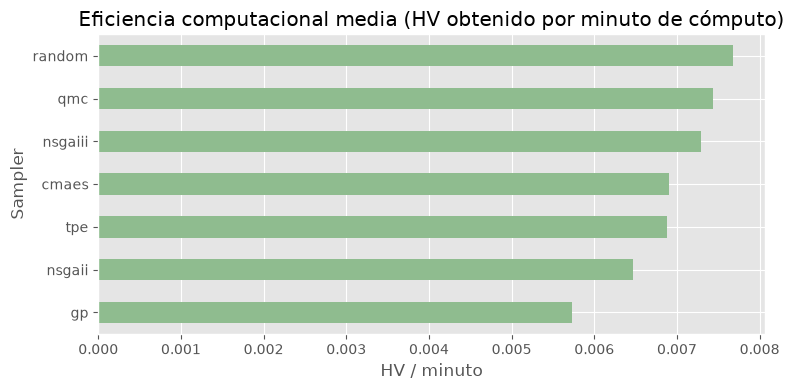

sampler
random     0.007676
qmc        0.007431
nsgaiii    0.007288
cmaes      0.006897
tpe        0.006876
nsgaii     0.006468
gp         0.005730
Name: hv_per_minute, dtype: float64

In [17]:
cost_benefit["hv_per_minute"] = cost_benefit["hv_final"] / cost_benefit["total_duration_min"]

efficiency_by_sampler = (
    cost_benefit
    .groupby("sampler")["hv_per_minute"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
efficiency_by_sampler.plot.barh(color="darkseagreen")
plt.title("Eficiencia computacional media (HV obtenido por minuto de cómputo)")
plt.xlabel("HV / minuto")
plt.ylabel("Sampler")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eficiencia_hv_por_minuto.png", dpi=300, bbox_inches="tight")
plt.show()

efficiency_by_sampler

## Área bajo la curva (AUC) de convergencia

El AUC normalizado resume en un único número la velocidad de convergencia de toda la curva (no solo el punto del 95%): un valor cercano a 1 indica que el *sampler* alcanza HV altos casi desde el principio y los mantiene.


In [18]:
def compute_auc(group):
    group = group.sort_values("number")
    trials = group["number"].values
    best_hv = group["best_so_far"].values

    raw_auc = np.trapezoid(best_hv, trials)
    max_possible_area = trials[-1] * 1.0 if trials[-1] > 0 else np.nan
    normalized_auc = raw_auc / max_possible_area if max_possible_area else np.nan

    return pd.Series({
        "hv_final": best_hv[-1],
        "auc_normalizado": normalized_auc,
    })


df_metrics = (
    df_complete
    .groupby(group_cols)
    .apply(compute_auc, include_groups=False)
    .reset_index()
)

df_metrics = df_metrics.merge(
    df_speed[["sampler", "problem", "trials_al_95pct", "minutos_al_95pct"]],
    on=group_cols,
)

df_metrics.to_csv(DATA_DIR / "metricas_convergencia.csv", index=False)
df_metrics.head()

,sampler,problem,hv_final,auc_normalizado,trials_al_95pct,minutos_al_95pct
0,cmaes,zcat1,0.254027,0.253307,1,1.355
1,cmaes,zcat10,0.112726,0.111508,3,6.668
2,cmaes,zcat11,0.210841,0.210151,2,1.569
3,cmaes,zcat12,0.195056,0.193421,0,0.487
4,cmaes,zcat13,0.249413,0.238581,8,39.628


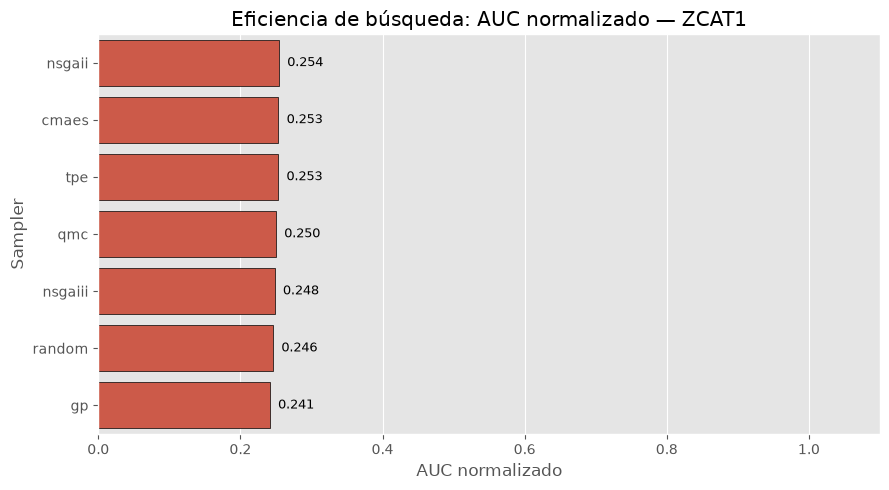

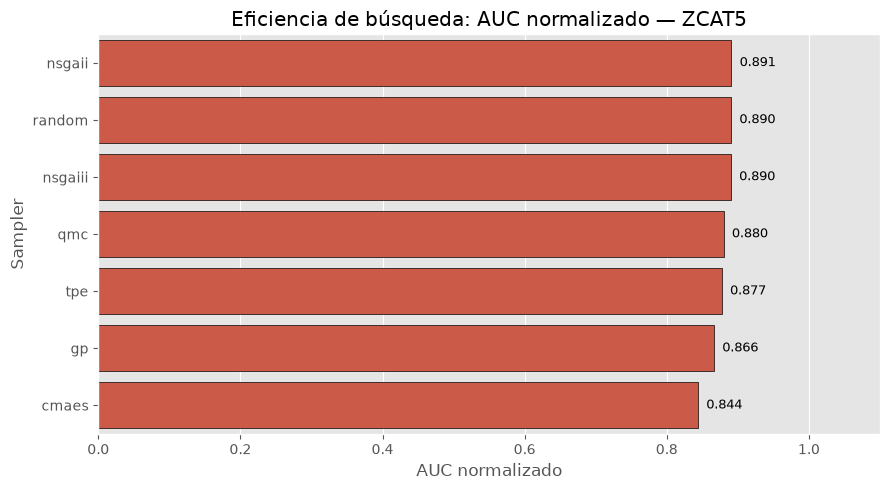

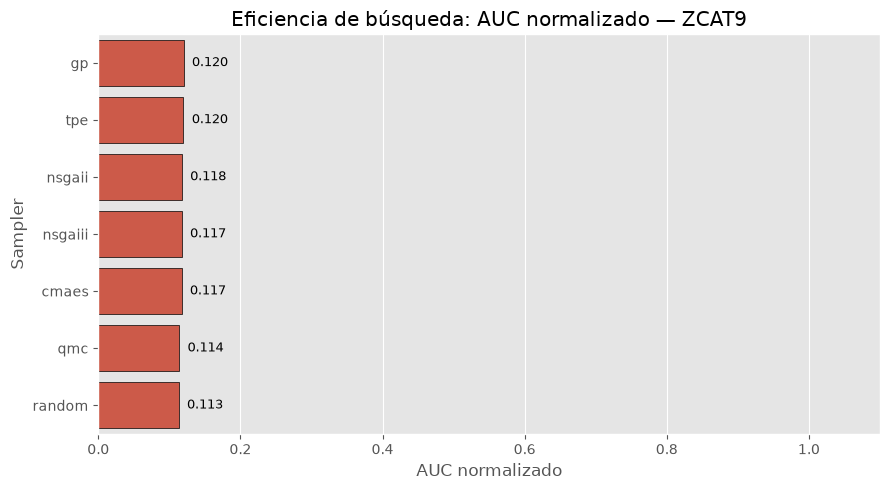

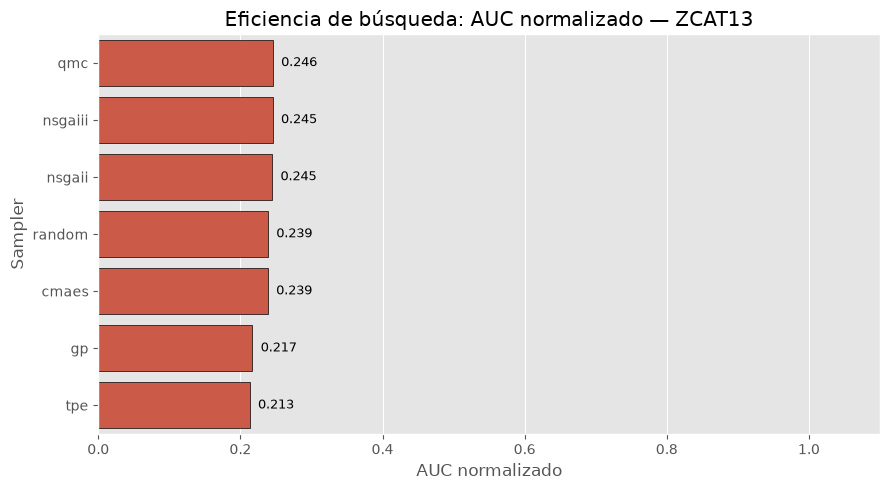

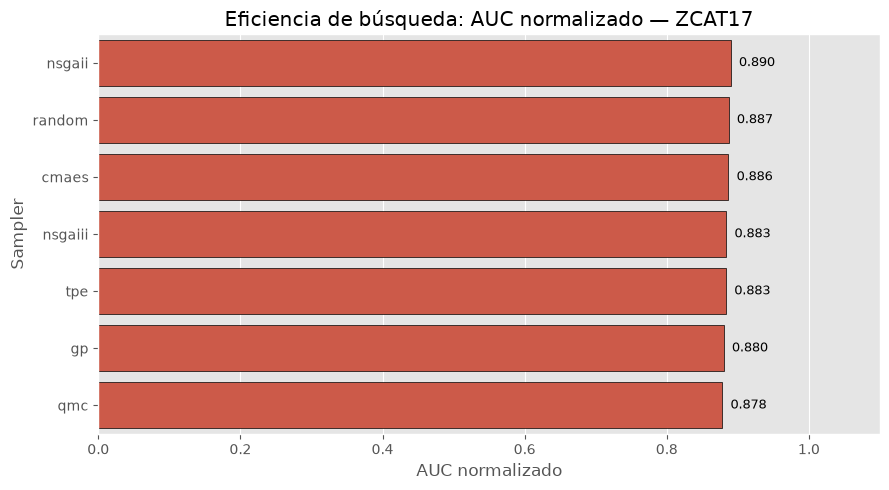

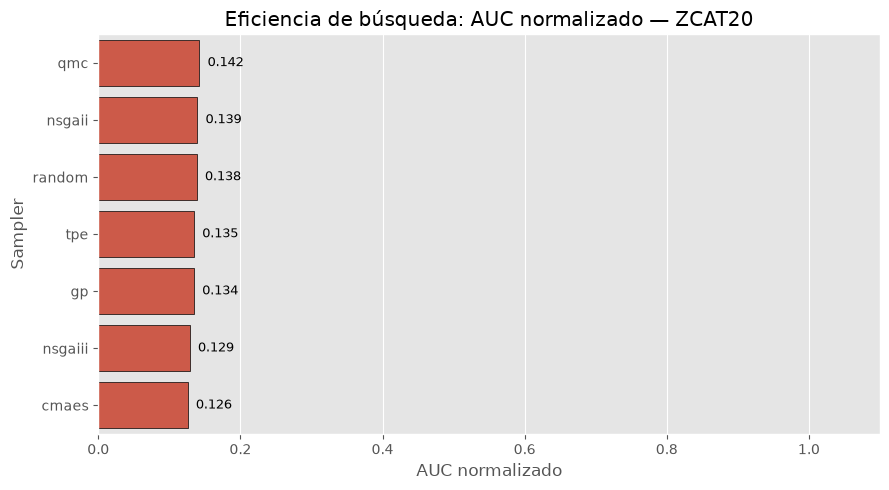

In [19]:
for problem in SELECTED_PROBLEMS:
    df_prob_metrics = (
        df_metrics[df_metrics["problem"] == problem]
        .sort_values("auc_normalizado", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x="auc_normalizado", y="sampler", data=df_prob_metrics, ax=ax, edgecolor="black")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=6, fontsize=9)

    ax.set_title(f"Eficiencia de búsqueda: AUC normalizado — {problem.upper()}")
    ax.set_xlabel("AUC normalizado")
    ax.set_ylabel("Sampler")
    ax.set_xlim(0, 1.1)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"auc_convergencia_{problem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Distribución de estados y uso del presupuesto de trials

Trials en estado distinto de `COMPLETE` (por ejemplo, `FAIL` o `PRUNED`) representan presupuesto de optimización desperdiciado. Un *sampler* con muchos fallos es menos fiable, incluso si su HV medio es bueno.


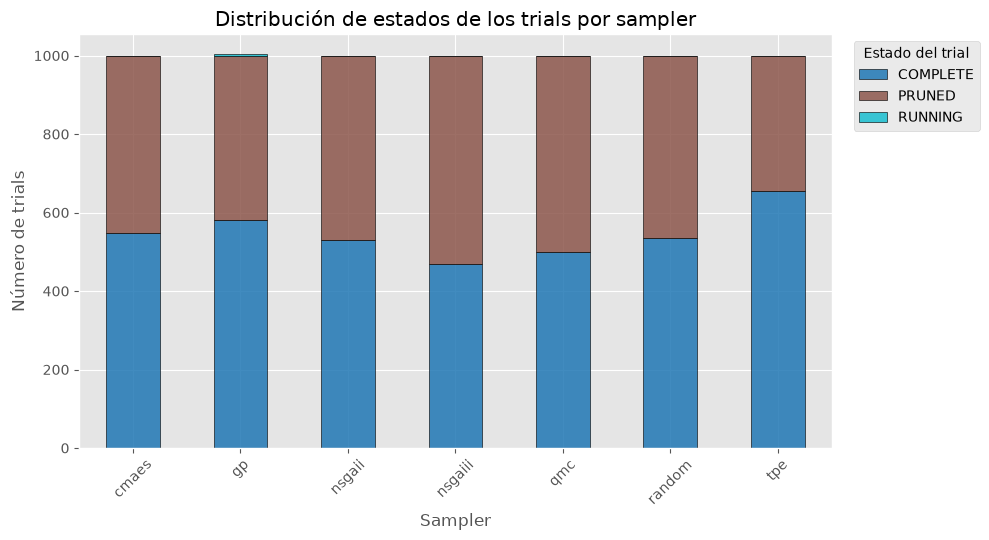

In [20]:
state_counts = df.groupby(["sampler", "state"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5.5))
state_counts.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", edgecolor="black", alpha=0.85)

ax.set_title("Distribución de estados de los trials por sampler")
ax.set_xlabel("Sampler")
ax.set_ylabel("Número de trials")
plt.xticks(rotation=45)
ax.legend(title="Estado del trial", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_estados.png", dpi=300, bbox_inches="tight")
state_counts.to_csv(DATA_DIR / "state_distribution.csv")
plt.show()

## Tabla resumen global

In [21]:
final_summary = (
    mean_speed
    .join(duration_by_sampler, how="outer")
    .join(efficiency_by_sampler.rename("hv_per_minute"), how="outer")
    .join(df_metrics.groupby("sampler")["auc_normalizado"].mean(), how="outer")
)

final_summary = final_summary.sort_values("minutos_al_95pct")
final_summary.round(4).to_csv(DATA_DIR / "convergence_summary_final.csv")

final_summary.round(4)

,trials_al_95pct,minutos_al_95pct,total_duration_hours,mean_study_duration_min,mean_trial_duration_s,trials_per_minute,hv_per_minute,auc_normalizado
sampler,,,,,,,,
nsgaii,5.00,7.3108,15.5966,46.7898,104.0258,0.5768,0.0065,0.2911
nsgaiii,7.25,10.0094,13.0996,39.2989,99.5885,0.6025,0.0073,0.2911
cmaes,5.45,10.1024,15.5886,46.7658,103.2597,0.5811,0.0069,0.2893
random,7.40,10.8320,14.4173,43.2518,96.2846,0.6232,0.0077,0.2905
gp,6.10,11.4140,29.1574,87.4721,176.0182,0.3409,0.0057,0.2811
tpe,7.65,12.6871,18.5495,55.6486,100.2657,0.5984,0.0069,0.2900
qmc,6.80,13.1706,14.6636,43.9907,104.7858,0.5726,0.0074,0.2892


## Conclusiones de este notebook

- **Velocidad de convergencia** (`trials_al_95pct`, `minutos_al_95pct`): identifica qué *sampler* llega antes al 95% de su HV final, tanto en número de evaluaciones como en tiempo real.
- **Coste computacional** (`duration_by_sampler`, `duracion_por_sampler.png`): muestra si esa rapidez en *trials* se traduce realmente en menos tiempo de cómputo, o si el coste por *trial* de algún método lo penaliza.
- **Escalabilidad** (`duracion_trial_vs_numero.png`): revela si algún *sampler* se ralentiza a medida que acumula *trials* (relevante si en el futuro se aumenta el presupuesto).
- **Relación coste-beneficio** (`coste_beneficio.png`, `hv_per_minute`): resume calidad y coste computacional en una única visión de conjunto, y permite argumentar no solo "qué sampler es mejor" sino "qué sampler es más rentable computacionalmente".

Esta tabla (`convergence_summary_final.csv`) puede combinarse con `ranking_summary.csv` (notebook 02) y `statistical_summary.csv` (notebook 03) para la tabla comparativa final del capítulo de resultados del TFM.
